# **Healthcare Patient Analytics Exploration**

## **Project Overview**

This project explores healthcare admission data using Python to identify trends in patient demographics, hospital operations, length of stay, and healthcare outcomes.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## **Data Inspection**

### 1. Load Dataset

In [5]:
df = pd.read_csv("../data/healthcare_dataset.csv")

df.head()

,Patient_ID,Admission_Date,Discharge_Date,Age,Age_Group,Gender,Condition_Type,Department,Severity_Score,Length_of_Stay,Insurance_Type,Discharge_Status,Readmission_Within_30_Days,Clinical_Notes
0,1,2023-04-17,2023-04-28,51,41-60,Other,Heart Failure,ICU,6,11,Private,Home,No,Heart Failure managed during admission; status...
1,2,2023-04-13,2023-04-16,71,61+,Male,Asthma,Pediatrics,2,3,Medicare,Home,No,Clinical course involved Asthma; patient was h...
2,3,2023-03-29,2023-04-12,82,61+,Other,Heart Failure,ICU,9,14,Medicare,Expired,No,Patient case: Heart Failure. Final status: Exp...
3,4,2023-11-05,2023-11-14,23,13-24,Male,Appendicitis,Surgery,6,9,Private,Home,No,Patient treated for Appendicitis. Discharge ou...
4,5,2023-10-21,2023-10-29,1,0-12,Male,Asthma,Pediatrics,4,8,Private,Home,No,Patient case: Asthma. Final status: Home.


### 2. Dataset Overview

In [6]:
df.shape

(500, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Patient_ID                  500 non-null    int64
 1   Admission_Date              500 non-null    str  
 2   Discharge_Date              500 non-null    str  
 3   Age                         500 non-null    int64
 4   Age_Group                   500 non-null    str  
 5   Gender                      500 non-null    str  
 6   Condition_Type              500 non-null    str  
 7   Department                  500 non-null    str  
 8   Severity_Score              500 non-null    int64
 9   Length_of_Stay              500 non-null    int64
 10  Insurance_Type              500 non-null    str  
 11  Discharge_Status            500 non-null    str  
 12  Readmission_Within_30_Days  500 non-null    str  
 13  Clinical_Notes              500 non-null    str  
dtypes: int64(4), str(10)


### 3. Data Quality Checks

In [8]:
df.isnull().sum()

Patient_ID                    0
Admission_Date                0
Discharge_Date                0
Age                           0
Age_Group                     0
Gender                        0
Condition_Type                0
Department                    0
Severity_Score                0
Length_of_Stay                0
Insurance_Type                0
Discharge_Status              0
Readmission_Within_30_Days    0
Clinical_Notes                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Patient_ID,Age,Severity_Score,Length_of_Stay
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,44.864000,5.234000,8.802000
std,144.481833,27.434044,2.110011,2.795429
min,1.000000,0.000000,1.000000,2.000000
25%,125.750000,22.000000,4.000000,7.000000
50%,250.500000,45.000000,5.000000,9.000000
75%,375.250000,67.000000,7.000000,11.000000
max,500.000000,94.000000,10.000000,15.000000


In [11]:
df.nunique()

Patient_ID                    500
Admission_Date                269
Discharge_Date                286
Age                            95
Age_Group                       5
Gender                          3
Condition_Type                 10
Department                      9
Severity_Score                 10
Length_of_Stay                 14
Insurance_Type                  4
Discharge_Status                3
Readmission_Within_30_Days      2
Clinical_Notes                 86
dtype: int64

In [12]:
df["Department"].value_counts()

Department
ICU                 100
Geriatrics           59
Orthopedics          56
General Medicine     55
Pulmonology          53
Surgery              49
Obstetrics           47
Pediatrics           42
Endocrinology        39
Name: count, dtype: int64

In [13]:
df["Discharge_Status"].value_counts()

Discharge_Status
Home                    393
Transferred to Rehab     97
Expired                  10
Name: count, dtype: int64

In [14]:
df["Readmission_Within_30_Days"].value_counts()

Readmission_Within_30_Days
No     412
Yes     88
Name: count, dtype: int64

### Dataset Observations
- The dataset comprises 500 patient records with 14 variables covering demographics, clinical data, operations, and outcomes.
- Numeric variables include age, severity score, and length of stay.
- Date variables require conversion from string format into datetime format.
- Requires categorical frequency checks, with length of stay and readmission status serving as primary metrics.

## **Data Cleaning**

### 1. Convert Data Types

In [15]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

## **Feature Engineering**

### 1. Admission Month Field

In [16]:
df["Admission_Month"] = df["Admission_Date"].dt.month_name()

### 2. High Severity Field

In [17]:
df["High_Severity"] = df["Severity_Score"] >= 8

### 3. Long Stay Field

In [18]:
df["Long_Stay"] = df["Length_of_Stay"] > 7

### 4. Weekend Field

In [19]:
df["Weekend_Admission"] = df["Admission_Date"].dt.dayofweek >= 5

## **Exploratory Analysis**

### **1. Patient Demographics**

### Age Distribution

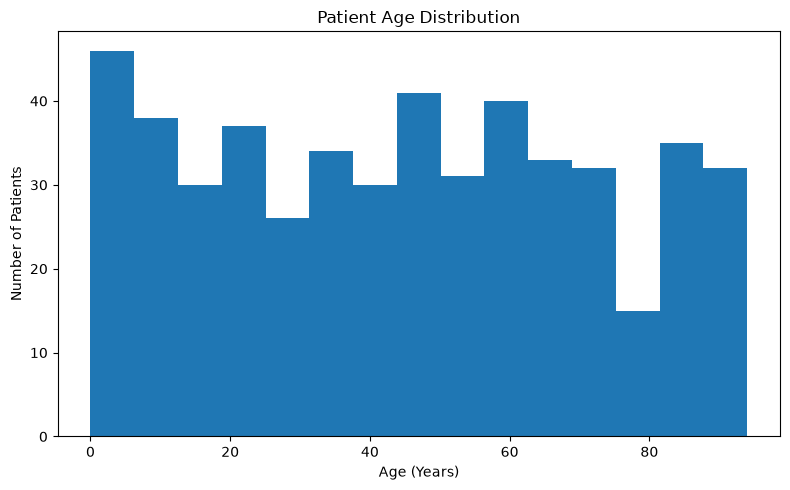

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Patient Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

The graph shows a fairly uniform distribution of patients across all age groups from childhood to over 90 years old. This indicates the dataset includes a broad range of patient ages rather than being concentrated within a single age group.

### Gender Distribution

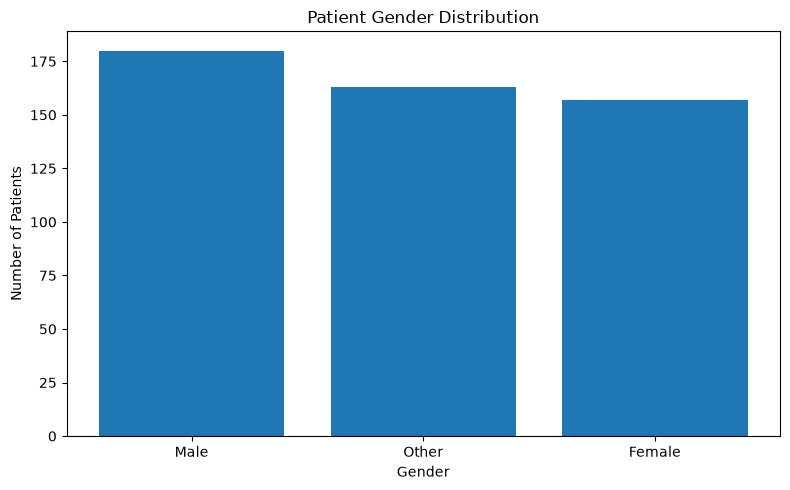

In [21]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Patient Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

The graph shows a nearly equal distribution of patients across the three recorded gender categories, with male patients appearing slightly more frequently than the other groups.

### Age Groups

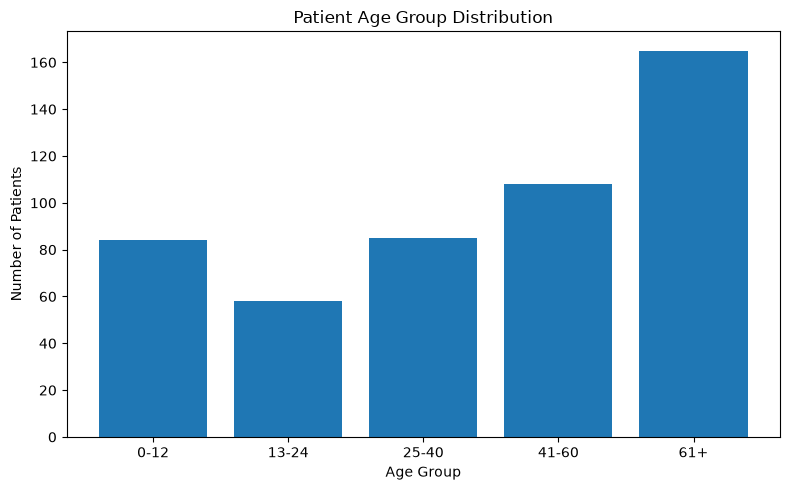

In [22]:
age_group_counts = df["Age_Group"].value_counts().sort_index(ascending=True)

plt.figure(figsize=(8,5))

plt.bar(age_group_counts.index, age_group_counts.values)

plt.title("Patient Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

The graph shows that patients aged 61+ accounted for the largest share of admissions, followed by those aged 41–60. This indicates that older adults represented the largest patient group within the dataset.

### **2. Clinical Analysis**

### Most Common Conditions

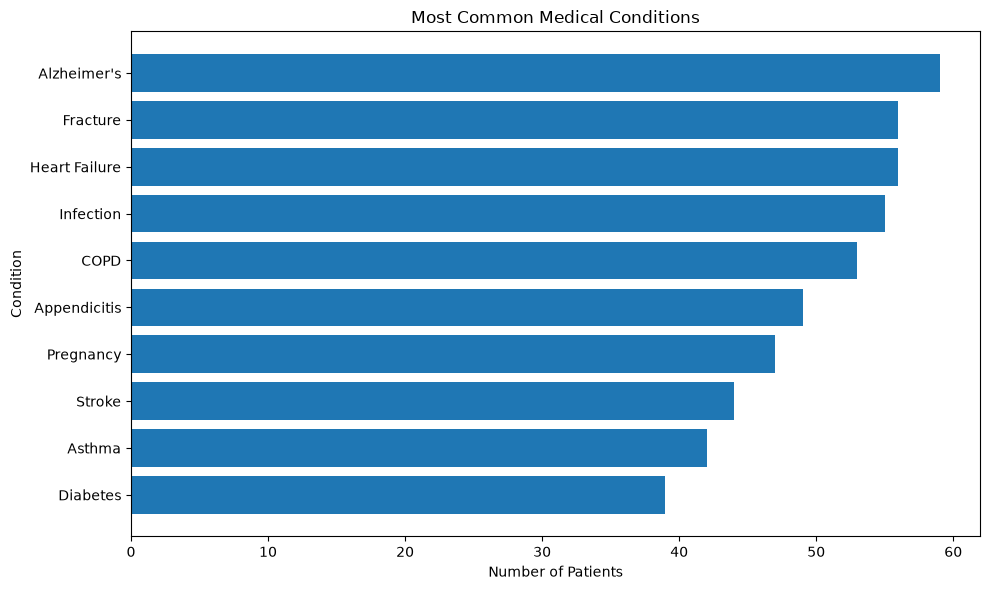

In [23]:
condition_type_counts = df["Condition_Type"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(condition_type_counts.index, condition_type_counts.values)

plt.title("Most Common Medical Conditions")
plt.xlabel("Number of Patients")
plt.ylabel("Condition")

plt.tight_layout()
plt.show()

Alzheimer's was the most frequently recorded condition, followed closely by Fracture and Heart Failure, while Diabetes had the fewest recorded admissions.

### Severity by Condition

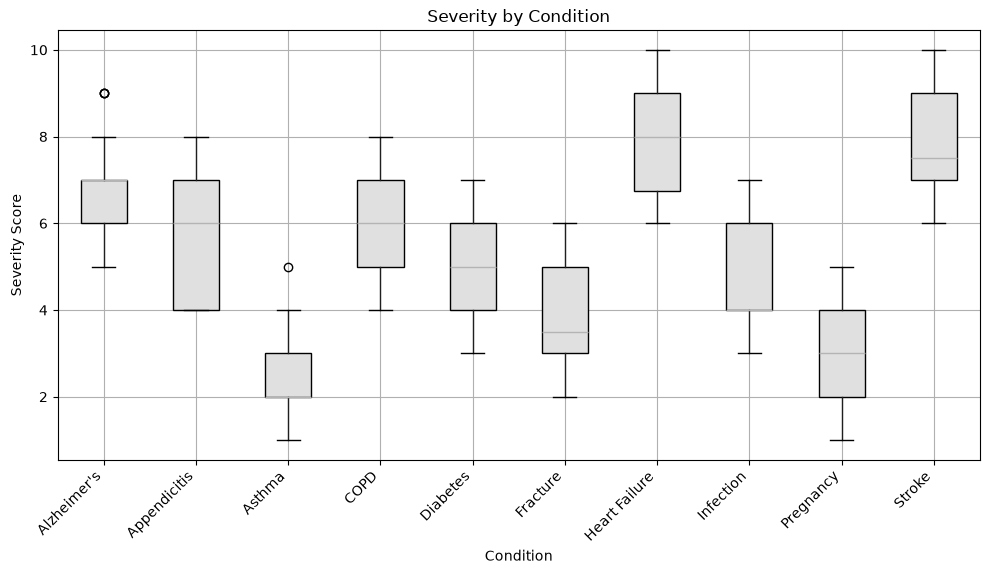

In [24]:
df.boxplot(column="Severity_Score", by="Condition_Type", figsize=(10, 6),
  patch_artist=True,
  boxprops=dict(facecolor='#e0e0e0', color='black')) 

plt.title("Severity by Condition")
plt.suptitle("") 
plt.xlabel("Condition")
plt.ylabel("Severity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Heart Failure and Stroke patients generally exhibited the highest severity scores, suggesting these conditions were associated with more clinically complex cases in this dataset. Asthma and Pregnancy showed comparatively lower severity scores.

### **3. Hospital Operations**

### LOS Distribution

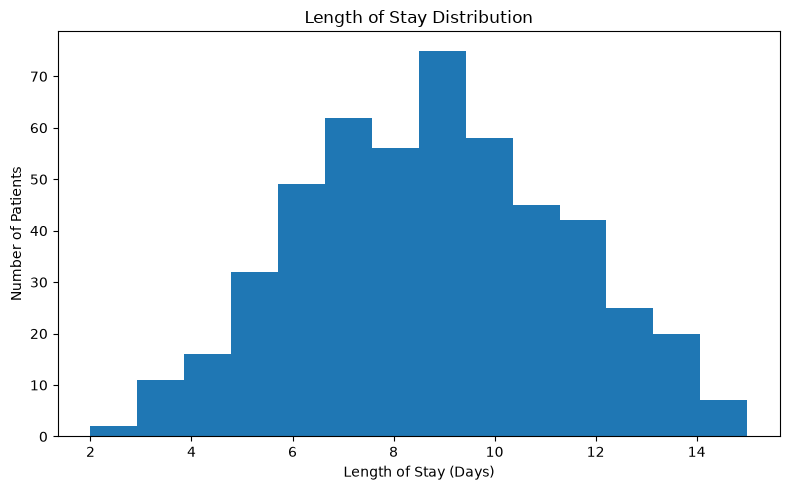

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Length_of_Stay"],
    bins=14
)

plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

The graph shows that most patients remained hospitalized for approximately 7 to 10 days, with the peak admission frequency occurring around 9 days. Stays shorter than 4 days or longer than 13 days were relatively rare, reflecting a bell-shaped distribution centered around a roughly one-to-and-a-half-week stay.

### Admissions by Month

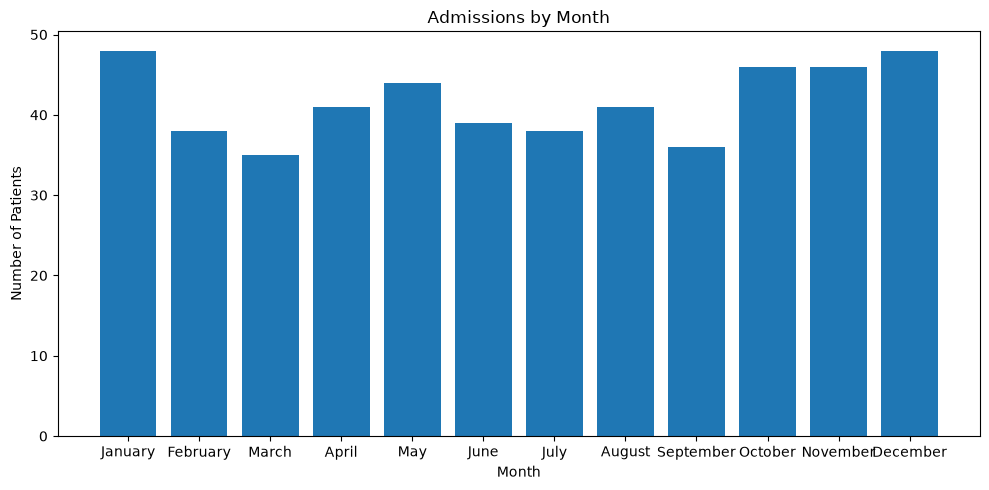

In [26]:
month_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
df["Admission_Month"] = pd.Categorical(df["Admission_Month"], categories=month_order, ordered=True)

month_counts = df["Admission_Month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(month_counts.index, month_counts.values)

plt.title("Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Monthly admissions remained relatively stable throughout the year, with only minor fluctuations between months. January and December recorded the highest admission volumes, while March had the fewest admissions.

### Departments with Most Patients

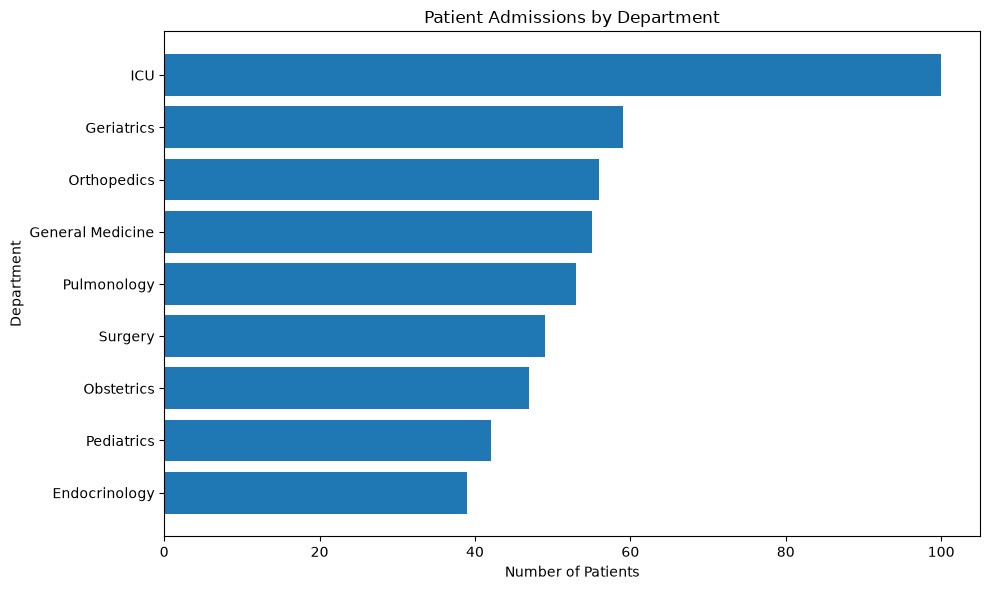

In [27]:
department_counts = df["Department"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(department_counts.index, department_counts.values)

plt.title("Patient Admissions by Department")
plt.xlabel("Number of Patients")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

The graph shows that the ICU recorded the highest number of patient admissions by a wide margin, reaching 100 patients. This is followed by Geriatrics and Orthopedics, while Endocrinology saw the lowest volume of cases among all listed departments.

### Average LOS by Department

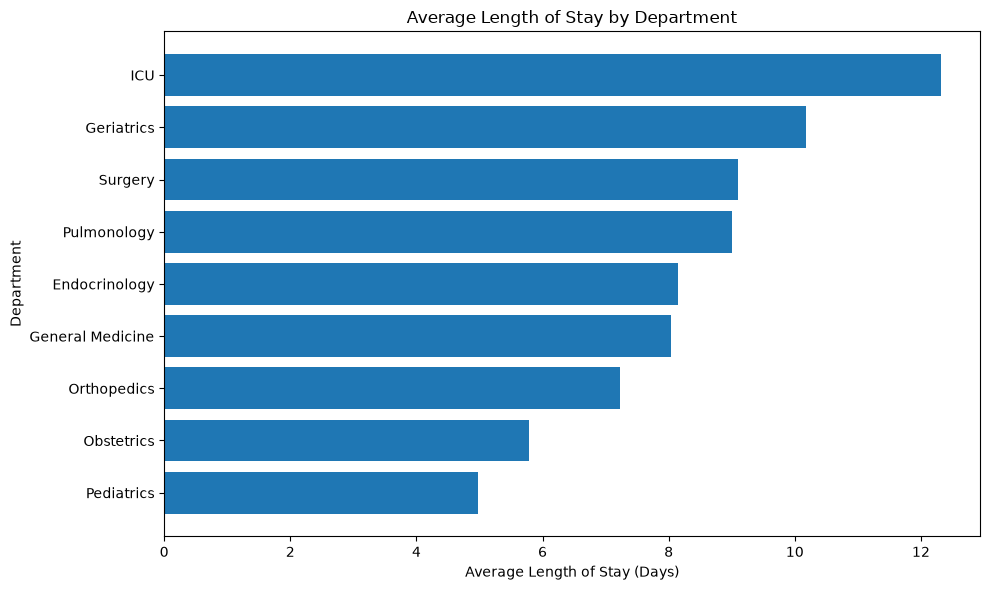

In [28]:
avg_los_department = (
    df.groupby("Department")["Length_of_Stay"]
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(avg_los_department.index, avg_los_department.values)

plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

The graph shows that the ICU recorded the highest average length of stay at over 12 days, followed closely by Geriatrics. In contrast, Pediatrics saw the shortest average stay, and Oncology was not represented in this dataset.

### **4. Readmissions**

### Readmission Rates

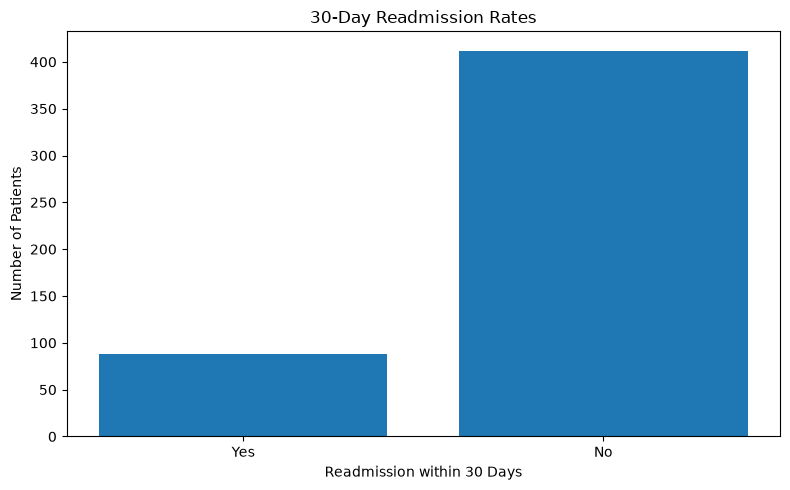

In [29]:
readmission_counts = df["Readmission_Within_30_Days"].value_counts().sort_index(ascending=False)

plt.figure(figsize=(8,5))

plt.bar(readmission_counts.index, readmission_counts.values)

plt.title("30-Day Readmission Rates")
plt.xlabel("Readmission within 30 Days")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Most patients were not readmitted within 30 days, while only a small proportion returned following discharge.

### Readmissions by Severity

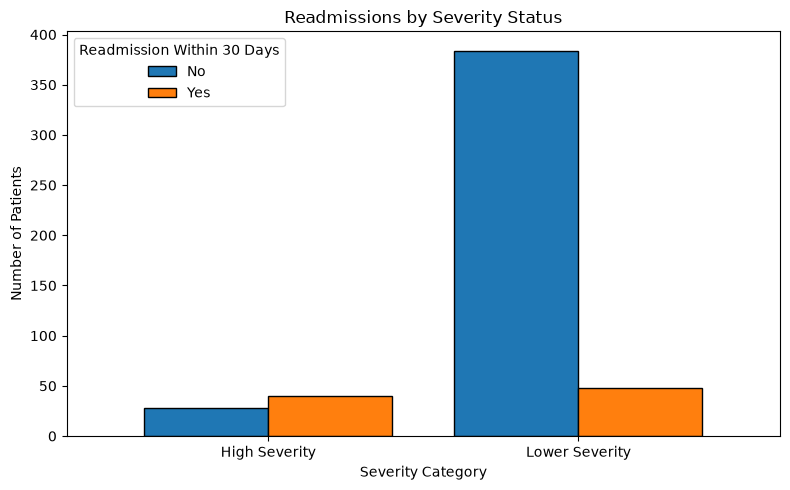

In [ ]:
severity_counts = pd.crosstab(
    df["High_Severity"].map({
        True:"High Severity",
        False:"Lower Severity"
    }), 
    df["Readmission_Within_30_Days"]
)

severity_counts.plot(kind="bar", figsize=(8, 5), width=0.8, edgecolor="black")

plt.title("Readmissions by Severity Status")
plt.xlabel("Severity Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0) 

plt.legend(title="Readmission Within 30 Days")

plt.tight_layout()
plt.show()


Although lower-severity patients accounted for more readmissions in absolute numbers, the proportion of readmitted patients was substantially higher within the high-severity group.

### **5. Relationships**

### Severity vs LOS

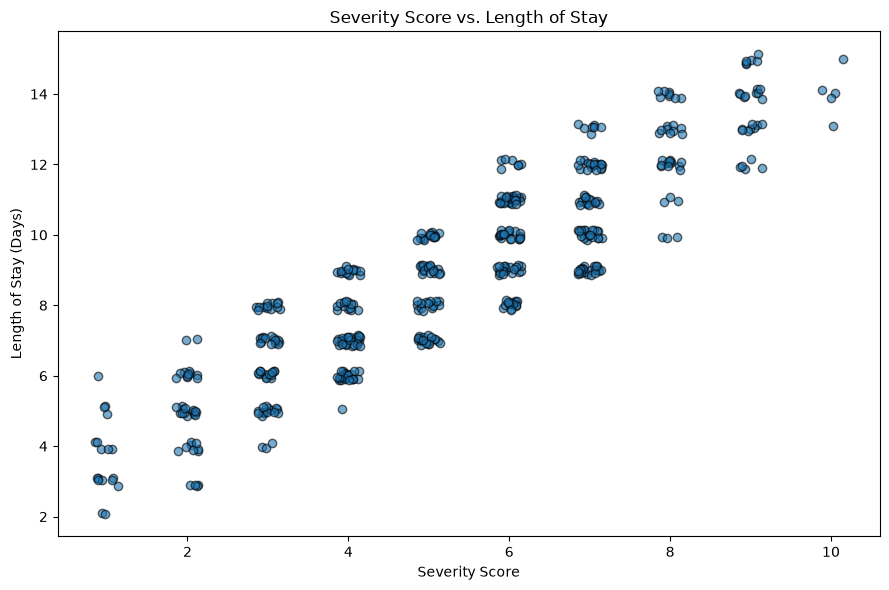

In [31]:
plt.figure(figsize=(9, 6))

jitter_x = df["Severity_Score"] + np.random.uniform(-0.15, 0.15, size=len(df))
jitter_y = df["Length_of_Stay"] + np.random.uniform(-0.15, 0.15, size=len(df))

plt.scatter(jitter_x, jitter_y, alpha=0.6, edgecolor="black")

plt.title("Severity Score vs. Length of Stay")
plt.xlabel("Severity Score")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

The scatter plot shows a strong positive relationship between severity score and length of stay. Patients with higher severity scores consistently experienced longer hospital stays, with stays rising from around 2–6 days for a severity score of 1 up to 12–15 days for a severity score of 10.

## **Business Insights**

- Patients with higher severity scores generally experienced longer hospital stays.

- ICU admissions accounted for the highest volume of cases and the longest average length of stay.

- Patients aged 61 years and older represented the largest admission group.

- Alzheimer's was the most common condition, while Heart Failure and Stroke were associated with the highest severity scores.

- High-severity patients experienced a disproportionately higher rate of 30-day readmissions.

- Monthly admissions remained highly stable across the year with no major seasonal fluctuations.